In [1]:
import os
os.listdir()


['.ipynb_checkpoints',
 'all_tickets_processed_improved_v3.csv',
 'support_ticket_classification.ipynb',
 'tfidf_vectorizer.pkl',
 'ticket_classifier_model.pkl']

In [2]:
df = pd.read_csv("your_dataset.csv")
df.head()


NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")

df.head()


In [ ]:
df.columns


In [ ]:
df.info()


In [ ]:
df.isnull().sum()


In [ ]:
# Keep only important columns
df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]

df.head()


In [ ]:
df.isnull().sum()


In [ ]:
import nltk
import re
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


In [ ]:
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()  # tokenize
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)


In [ ]:
df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

df[['Ticket Description', 'cleaned_text']].head()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)


In [ ]:
X = vectorizer.fit_transform(df['cleaned_text'])


In [ ]:
X.shape


In [ ]:
y_category = df['Ticket Type']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)


In [ ]:
y_pred = model_category.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
df['combined_text'] = df['Ticket Description'] + " " + df['Ticket Type']


In [ ]:
df['combined_text'] = df['Ticket Subject'] + " " + df['Ticket Description']


In [ ]:
df = pd.read_csv("customer_support_tickets.csv")


In [ ]:
df['combined_text'] = df['Ticket Subject'] + " " + df['Ticket Description']


In [ ]:
df = df[['combined_text', 'Ticket Type', 'Ticket Priority']]


In [ ]:
df['cleaned_text'] = df['combined_text'].apply(clean_text)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])


In [ ]:
y_category = df['Ticket Type']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train, y_train)


In [ ]:
y_pred = model_category.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
import os
os.listdir()


In [ ]:
import pandas as pd

df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()


In [ ]:
df.columns


In [ ]:
df.info()


In [ ]:
import nltk
import re
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [ ]:
df['cleaned_text'] = df['Document'].apply(clean_text)

df[['Document', 'cleaned_text']].head()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)


In [ ]:
X = vectorizer.fit_transform(df['cleaned_text'])


In [ ]:
X.shape


In [ ]:
y = df['Topic_group']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
import pickle

# Save model
pickle.dump(model, open("ticket_classifier_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))


In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ticket Classification")
plt.show()

NameError: name 'y_test' is not defined

In [4]:
y = df['Topic_group']

NameError: name 'df' is not defined

In [5]:
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [6]:
df = pd.read_csv("all_tickets_processed_improved_v3.csv")
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [7]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['Document'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SUKANYA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['Document'].apply(clean_text)

df.head()

,Document,Topic_group,cleaned_text
0,connection with icon icon dear please setup ic...,Hardware,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,Hardware,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,Access,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,Miscellaneous,mail verification warning hi got attached plea...


In [9]:
pd.set_option('display.max_colwidth', None)
df.head()

,Document,Topic_group,cleaned_text
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware,connection icon icon dear please setup icon per icon engineers please let details needed thanks lead
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access,work experience user work experience user hi work experience student coming next name much appreciate duration thank
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware,requesting meeting requesting meeting hi please help follow equipments cable pc cord plug
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then re enter again save connected note complete resources granted once connected by cable browse tick want change after logging enter format enter log enter enter newly chosen then re enter again change clients suppliers about expire please touch person then communicate back encounter issues hesitate by accessing yours,Access,reset passwords external accounts expire days hi ask help update passwords colleagues thank pm expire days importance high hi received expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected cable machine note also follow steps detailed press ctrl alt delete pops change item enter format enter enter newly chosen enter submit displaying changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen enter save connected note complete resources granted connected cable browse tick want change logging enter format enter log enter enter newly chosen enter change clients suppliers expire please touch person communicate back encounter issues hesitate accessing
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous,mail verification warning hi got attached please addresses best regards monitoring analyst verification warning


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])

X.shape

(47837, 5000)

In [11]:
from sklearn.model_selection import train_test_split

y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8510660535117057
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



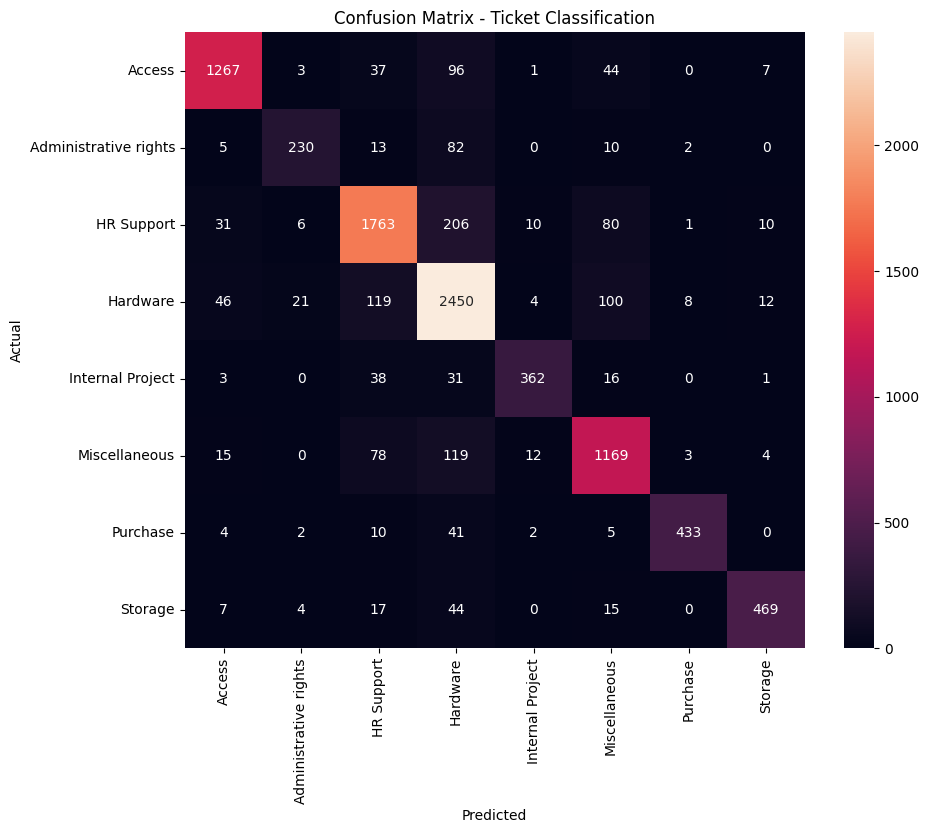

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ticket Classification")
plt.show()

In [17]:
def assign_priority(text):
    text = text.lower()
    
    high_keywords = ["urgent", "critical", "immediately", "down", "not working", "asap"]
    medium_keywords = ["request", "access", "issue", "error", "help"]
    
    for word in high_keywords:
        if word in text:
            return "High"
    
    for word in medium_keywords:
        if word in text:
            return "Medium"
    
    return "Low"

In [18]:
df["Predicted_Priority"] = df["Document"].apply(assign_priority)

df[["Document", "Predicted_Priority"]].head()

,Document,Predicted_Priority
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Low
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Low
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Medium
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then re enter again save connected note complete resources granted once connected by cable browse tick want change after logging enter format enter log enter enter newly chosen then re enter again change clients suppliers about expire please touch person then communicate back encounter issues hesitate by accessing yours,Medium
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Low


In [20]:
df["Predicted_Priority"].value_counts()

Predicted_Priority
Medium    22883
Low       20102
High       4852
Name: count, dtype: int64

The dataset does not contain labeled priority levels.
Therefore, a rule-based priority assignment system was implemented.

Priority levels are assigned using urgency-related keywords such as:

"urgent"

"critical"

"down"

"immediately"

This simulates real-world urgency detection in support systems.

In [ ]:
wc